# 🧠 AI-Assisted Brain Tumor Segmentation (BraTS 2021) 
**การพัฒนาแบบจำลองปัญญาประดิษฐ์เพื่อระบุตำแหน่งเนื้องอกในสมองด้วย Attention U-Net**

## 📖 บทนำ (Introduction)
ในแต่ละปี มีผู้ป่วยรายใหม่ที่ได้รับการวินิจฉัยว่าเป็นเนื้องอกในสมองและระบบประสาทส่วนกลางหลายแสนคนทั่วโลก การระบุตำแหน่งและขอบเขตของก้อนเนื้องอก (Tumor Segmentation) อย่างแม่นยำมีความสำคัญอย่างยิ่งต่อการวางแผนรังสีรักษาและการผ่าตัด แต่นี่คืองานที่ใช้เวลาและความเชี่ยวชาญสูงมากจากรังสีแพทย์ 

Notebook นี้คือการสร้าง **"ดวงตาที่สอง"** ให้กับแพทย์ โดยใช้เทคนิค Deep Learning ภายใต้สถาปัตยกรรม **Attention U-Net** 

### 💽 ชุดข้อมูลของเรา (The Dataset)
เราใช้ชุดข้อมูลจาก **RSNA-ASNR-MICCAI BraTS 2021** ซึ่งประกอบด้วยภาพสแกน MRI ของผู้ป่วยจำนวน 1,251 เคส โดยผู้ป่วย 1 คน จะมีภาพ 3D MRI 4 รูปแบบ (Modalities) ที่ให้ข้อมูลแตกต่างกัน ได้แก่:
1. **T1:** โครงสร้างเนื้อเยื่อสมองทั่วไป
2. **T1c (T1Gd):** ภาพที่ฉีดสารทึบรังสี ช่วยให้เห็นขอบเขตของเนื้องอกที่ยังมีเลือดไปเลี้ยงชัดเจนขึ้น
3. **T2:** แสดงพื้นที่ที่มีน้ำคั่ง (บวม) ได้ดี
4. **FLAIR:** ตัดสัญญาณน้ำในโพรงสมองออก ทำให้เห็นความผิดปกติใกล้โพรงสมองชัดเจน

และไฟล์ที่ 5 คือ **Seg (Segmentation Mask)** ซึ่งเป็นเฉลยจากทีมแพทย์ผู้เชี่ยวชาญ แบ่งเนื้องอกออกเป็น 3 บริเวณ (NCR, ED, ET)

### 🎯 แผนการดำเนินงาน (Our Roadmap)
1. **Patient-Level Data Loading:** โหลดข้อมูลโดยป้องกัน Data Leakage อย่างเด็ดขาด
2. **3D to 2D Slicing & Preprocessing:** สกัดภาพ 3D เป็น 2D ครอปเฉพาะสมอง และทำ Z-score Normalization
3. **Model Construction:** สร้าง Attention U-Net
4. **Training with Dice Loss:** ฝึกสอนโมเดลโดยจัดการกับปัญหา Class Imbalance
5. **Strict Evaluation:** ประเมินผลทางคลินิกด้วย Dice Score

## ⚙️ ส่วนที่ 1: การจัดการข้อมูล (Data Loader & Exploration)
หัวใจหลักของการทำโมเดลทางการแพทย์ที่ "ไม่หลอกตัวเอง" คือการป้องกัน **Data Leakage** 
เราจะไม่แบ่งข้อมูลจากการสุ่มภาพ 2D รวมๆ กัน แต่เราจะสุ่มแยก **รายชื่อผู้ป่วย (Patient IDs)** ออกเป็น 3 กลุ่มก่อน:
* **Train Set (70%):** สำหรับให้โมเดลเรียนรู้
* **Validation Set (15%):** สำหรับปรับจูนโมเดลระหว่างเทรน
* **Test Set (15%):** ชุดข้อมูลตาบอด (Blind set) ที่โมเดลไม่เคยเห็นมาก่อน เพื่อทดสอบประสิทธิภาพขั้นสุดท้าย

ในเซลล์ต่อไปนี้ เราจะเขียนโค้ดเพื่อเข้าไปสำรวจไฟล์ใน Dataset ดึงรายชื่อผู้ป่วยทั้งหมด และทดลองโหลดภาพ 3D ของผู้ป่วย 1 คน นำมาหั่นเป็นสไลซ์ 2D ตรงกลางสมอง เพื่อดูว่าภาพ T1, T1c, T2, FLAIR และ Mask มีหน้าตาเป็นอย่างไร

In [1]:
import tarfile
import os

# 1. ระบุตำแหน่งกล่องใบใหญ่ที่อยู่ใน Input
tar_path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"

# 2. ระบุโฟลเดอร์ปลายทางที่เราจะแกะของออกมาวางไว้ (Working Directory)
extract_path = "/kaggle/working/BraTS2021_Training_Data"

# ตรวจสอบว่าเคยแตกไฟล์ไปแล้วหรือยัง จะได้ไม่เสียเวลาทำซ้ำ
if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    print(f"📦 กำลังแตกไฟล์ {tar_path} \n⏳ อาจใช้เวลาประมาณ 2-5 นาที โปรดรอสักครู่...")
    
    # ทำการแตกไฟล์ .tar
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(path=extract_path)
        
    print("✅ แตกไฟล์สำเร็จเรียบร้อย! ข้อมูลพร้อมใช้งานแล้ว")
else:
    print("✅ โฟลเดอร์เป้าหมายมีอยู่แล้ว ไม่ต้องแตกไฟล์ซ้ำ พร้อมไปต่อได้เลย!")

📦 กำลังแตกไฟล์ /kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar 
⏳ อาจใช้เวลาประมาณ 2-5 นาที โปรดรอสักครู่...


/tmp/ipykernel_55/1830716862.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


✅ แตกไฟล์สำเร็จเรียบร้อย! ข้อมูลพร้อมใช้งานแล้ว


✅ ค้นพบข้อมูลผู้ป่วยทั้งหมด: 1251 เคส
📊 แบ่งข้อมูล (Patient-Level): Train=875, Val=188, Test=188

🔍 สำรวจข้อมูลผู้ป่วย: BraTS2021_00100
📏 ขนาดของภาพ 3D (Shape): (240, 240, 155)


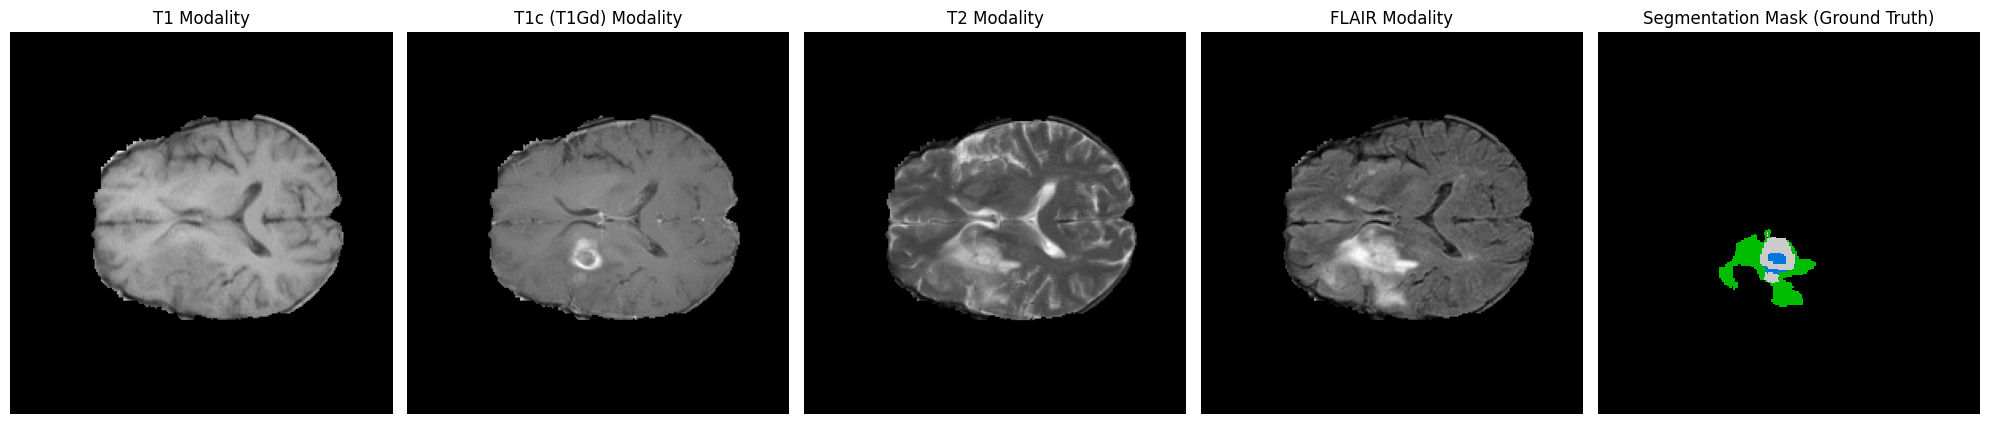

In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. กำหนด Path ของ Dataset ใน Kaggle
# (คุณอาจต้องปรับ path นี้ตามชื่อ Dataset ที่คุณ Add เข้ามาใน Notebook จริงๆ)
# ปกติมักจะอยู่ที่ /kaggle/input/brats20-dataset-training-validation หรือคล้ายกัน
DATASET_PATH = "/kaggle/working/BraTS2021_Training_Data" 

# ค้นหาโฟลเดอร์ผู้ป่วยทั้งหมดที่มีคำว่า 'BraTS2021' 
# และมีโฟลเดอร์ย่อยข้างใน (เพื่อหลีกเลี่ยงการนับไฟล์ .tar ตรงๆ ในเบื้องต้น)
all_patient_paths = glob.glob(os.path.join(DATASET_PATH, "**", "BraTS2021_*"), recursive=True)

# คัดกรองเอาเฉพาะที่เป็น "โฟลเดอร์" ของผู้ป่วยจริงๆ (ลบไฟล์ .tar ออกจากลิสต์)
patient_folders = [p for p in all_patient_paths if os.path.isdir(p)]
patient_folders = sorted(list(set(patient_folders)))

print(f"✅ ค้นพบข้อมูลผู้ป่วยทั้งหมด: {len(patient_folders)} เคส")

if len(patient_folders) > 0:
    # 2. การแบ่งข้อมูลระดับผู้ป่วย (Patient-Level Split) เพื่อป้องกัน Data Leakage
    # แบ่ง Train 70%, Val 15%, Test 15%
    train_patients, temp_patients = train_test_split(patient_folders, test_size=0.30, random_state=42)
    val_patients, test_patients = train_test_split(temp_patients, test_size=0.50, random_state=42)

    print(f"📊 แบ่งข้อมูล (Patient-Level): Train={len(train_patients)}, Val={len(val_patients)}, Test={len(test_patients)}")

    # 3. ทดลองโหลดข้อมูลผู้ป่วย 1 คน (เพื่อตรวจสอบว่าไฟล์อ่านได้ปกติ)
    sample_patient = train_patients[0]
    patient_id = os.path.basename(sample_patient)
    print(f"\n🔍 สำรวจข้อมูลผู้ป่วย: {patient_id}")
    
    # กำหนด path ของไฟล์แต่ละประเภท (.nii.gz)
    t1_path = os.path.join(sample_patient, f"{patient_id}_t1.nii.gz")
    t1ce_path = os.path.join(sample_patient, f"{patient_id}_t1ce.nii.gz")
    t2_path = os.path.join(sample_patient, f"{patient_id}_t2.nii.gz")
    flair_path = os.path.join(sample_patient, f"{patient_id}_flair.nii.gz")
    seg_path = os.path.join(sample_patient, f"{patient_id}_seg.nii.gz")
    
    # ฟังก์ชันอ่านไฟล์ NIfTI และแปลงเป็น Numpy Array
    def load_nifti(file_path):
        if os.path.exists(file_path):
            return nib.load(file_path).get_fdata()
        return None

    img_t1 = load_nifti(t1_path)
    img_t1ce = load_nifti(t1ce_path)
    img_t2 = load_nifti(t2_path)
    img_flair = load_nifti(flair_path)
    img_seg = load_nifti(seg_path)

    if img_t1 is not None:
        print(f"📏 ขนาดของภาพ 3D (Shape): {img_t1.shape}") # ปกติจะเป็น (240, 240, 155)
        
        # เลือกสไลซ์ 2D ตรงกลางๆ สมองมาแสดงผล (เช่น สไลซ์ที่ 75 จาก 155 แผ่นตามแกน Z)
        slice_idx = img_t1.shape[2] // 2
        
        plt.figure(figsize=(20, 5))
        
        plt.subplot(1, 5, 1)
        plt.imshow(img_t1[:, :, slice_idx], cmap='gray')
        plt.title('T1 Modality')
        plt.axis('off')
        
        plt.subplot(1, 5, 2)
        plt.imshow(img_t1ce[:, :, slice_idx], cmap='gray')
        plt.title('T1c (T1Gd) Modality')
        plt.axis('off')
        
        plt.subplot(1, 5, 3)
        plt.imshow(img_t2[:, :, slice_idx], cmap='gray')
        plt.title('T2 Modality')
        plt.axis('off')
        
        plt.subplot(1, 5, 4)
        plt.imshow(img_flair[:, :, slice_idx], cmap='gray')
        plt.title('FLAIR Modality')
        plt.axis('off')
        
        plt.subplot(1, 5, 5)
        # เคล็ดลับ: Mask จะมีค่า 0 (ปกติ), 1 (NCR), 2 (ED), 4 (ET) 
        # เราตั้งค่า cmap เป็นพิกัดสีเพื่อให้เห็นส่วนที่ทับซ้อนชัดเจน
        plt.imshow(img_seg[:, :, slice_idx], cmap='nipy_spectral', interpolation='none')
        plt.title('Segmentation Mask (Ground Truth)')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("❌ ไม่พบไฟล์ .nii.gz ในโฟลเดอร์ (อาจเป็นเพราะโครงสร้าง Path ไม่ถูกต้อง ต้องตรวจสอบอีกครั้ง)")
else:
    print("❌ ไม่พบโฟลเดอร์ผู้ป่วย โปรดตรวจสอบ DATASET_PATH หรือดูว่า Kaggle แตกไฟล์ .tar ให้หรือยัง")

## 🧹 ส่วนที่ 2: การทำความสะอาดและเตรียมข้อมูล (Data Preprocessing)
ก่อนที่จะสร้าง Dataloader เราต้องมีกระบวนการ "เตรียมภาพ" ให้มีคุณภาพสูงที่สุด เพื่อให้โมเดลเรียนรู้ได้ดีและมี F1-Score สูงสุด โดยมีขั้นตอนดังนี้:

1. **Cropping (ตัดขอบดำ):** ค้นหา Bounding Box ของเนื้อสมอง เพื่อตัดพื้นที่สีดำ (Background) รอบนอกออก ช่วยให้ AI โฟกัสเฉพาะเนื้อสมองได้เต็มพิกเซล
2. **Z-Score Normalization:** ปรับความสว่างของภาพให้เป็นมาตรฐานเดียวกัน (Mean=0, Std=1) โดยคำนวณเฉพาะพิกเซลที่ไม่ใช่สีดำ 
3. **Resizing:** ปรับขนาดภาพจากที่ตัดขอบแล้ว ให้กลายเป็น $256 \times 256$ พิกเซล ตามข้อกำหนดของสถาปัตยกรรมโมเดล
4. **Channel Stacking:** นำภาพ 2D ของ T1, T1c, T2, FLAIR มาซ้อนกันเป็น 4 Channels เพื่อให้ AI นำข้อมูลทุก Modality มาประกอบการตัดสินใจ

✂️ ครอปพื้นที่สมองจากพิกัด: X[46:189], Y[46:216], Z[0:142]


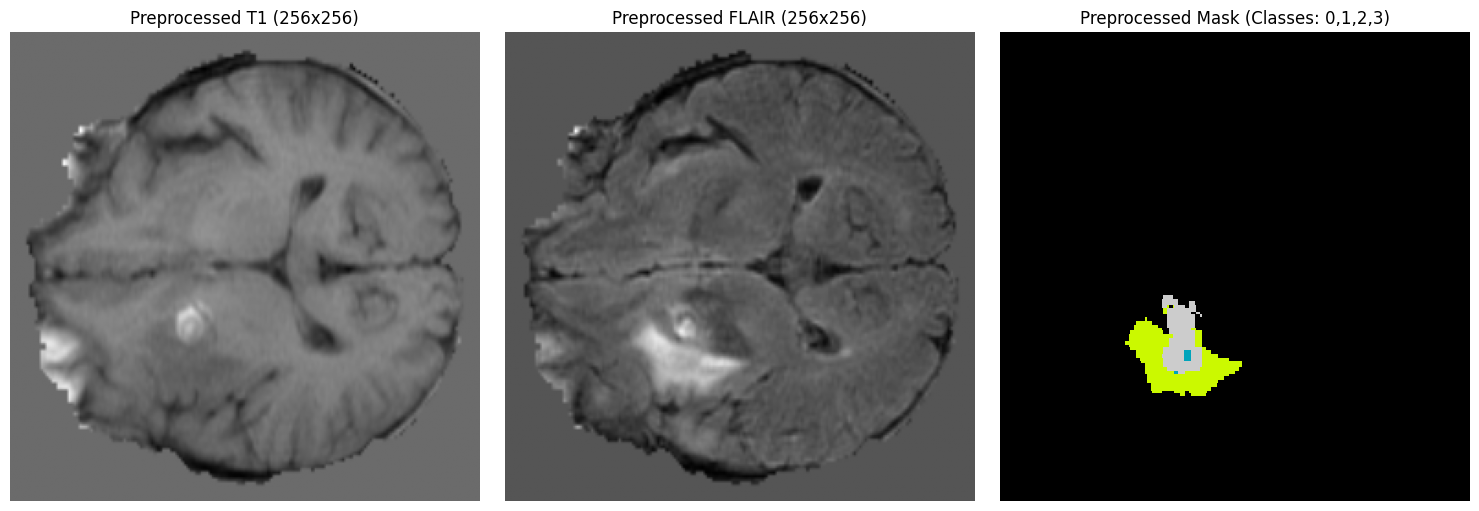

📏 ขนาดภาพหลังจากเตรียมข้อมูล: (256, 256)


In [3]:
import cv2

# --- 1. ฟังก์ชันหาขอบเขตสมองเพื่อตัดขอบดำ (Cropping) ---
def get_brain_bounding_box(volume):
    # หาพิกัด (X, Y, Z) ที่มีค่ามากกว่า 0 (ไม่ใช่พื้นหลังสีดำ)
    mask = volume > 0
    coords = np.array(np.nonzero(mask))
    
    if coords.shape[1] == 0:
        return 0, volume.shape[0], 0, volume.shape[1], 0, volume.shape[2]
        
    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()
    
    # เผื่อขอบ (Padding) ไว้นิดหน่อยเพื่อไม่ให้ชิดเนื้อสมองเกินไป
    return (max(0, x_min-5), min(volume.shape[0], x_max+5),
            max(0, y_min-5), min(volume.shape[1], y_max+5),
            max(0, z_min-5), min(volume.shape[2], z_max+5))

# --- 2. ฟังก์ชันปรับมาตรฐานความสว่าง (Z-Score Normalization) ---
def normalize_z_score(image):
    mask = image > 0 # คำนวณเฉพาะบริเวณที่มีสมอง (ตัดสีดำออก)
    if mask.sum() > 0:
        mean = image[mask].mean()
        std = image[mask].std()
        image = (image - mean) / (std + 1e-8)
        image[~mask] = 0 # บังคับให้พื้นหลังกลับเป็น 0 เหมือนเดิม
    return image

# ==========================================
# 🧪 ทดลองรัน Preprocessing กับผู้ป่วยคนเดิม
# ==========================================

# หา Bounding Box จาก T1 (ใช้เป็นตัวอ้างอิงของทุก Modality)
x_min, x_max, y_min, y_max, z_min, z_max = get_brain_bounding_box(img_t1)
print(f"✂️ ครอปพื้นที่สมองจากพิกัด: X[{x_min}:{x_max}], Y[{y_min}:{y_max}], Z[{z_min}:{z_max}]")

# ตัดขอบในรูปแบบ 3D Volume
crop_t1 = img_t1[x_min:x_max, y_min:y_max, z_min:z_max]
crop_t1ce = img_t1ce[x_min:x_max, y_min:y_max, z_min:z_max]
crop_t2 = img_t2[x_min:x_max, y_min:y_max, z_min:z_max]
crop_flair = img_flair[x_min:x_max, y_min:y_max, z_min:z_max]
crop_seg = img_seg[x_min:x_max, y_min:y_max, z_min:z_max]

# เลือกสไลซ์ 2D ตรงกลางจากภาพที่ครอปแล้ว
new_slice_idx = crop_t1.shape[2] // 2

slice_t1 = crop_t1[:, :, new_slice_idx]
slice_t1ce = crop_t1ce[:, :, new_slice_idx]
slice_t2 = crop_t2[:, :, new_slice_idx]
slice_flair = crop_flair[:, :, new_slice_idx]
slice_seg = crop_seg[:, :, new_slice_idx]

# Normalization 
norm_t1 = normalize_z_score(slice_t1)
norm_flair = normalize_z_score(slice_flair)

# ปรับขนาดภาพให้เป็น 256x256
img_size = (256, 256)
res_t1 = cv2.resize(norm_t1, img_size, interpolation=cv2.INTER_LINEAR)
res_flair = cv2.resize(norm_flair, img_size, interpolation=cv2.INTER_LINEAR)

# ⚠️ ข้อควรระวังขั้นสุด: การ Resize Mask ต้องใช้ INTER_NEAREST 
# เพื่อไม่ให้ค่า Label (0,1,2,4) ถูกเบลอจนกลายเป็นจุดทศนิยม (เช่น 1.5) ซึ่งโมเดลจะงงทันที
res_seg = cv2.resize(slice_seg, img_size, interpolation=cv2.INTER_NEAREST)

# เปลี่ยน Label 4 ให้เป็น 3 เพื่อให้คลาสเรียงกัน (0, 1, 2, 3) ง่ายต่อการเทรน
res_seg[res_seg == 4] = 3

# พล็อตภาพเปรียบเทียบ
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(res_t1, cmap='gray')
plt.title('Preprocessed T1 (256x256)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(res_flair, cmap='gray')
plt.title('Preprocessed FLAIR (256x256)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(res_seg, cmap='nipy_spectral', interpolation='none')
plt.title('Preprocessed Mask (Classes: 0,1,2,3)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"📏 ขนาดภาพหลังจากเตรียมข้อมูล: {res_t1.shape}")

## 🗂️ ส่วนที่ 3: การสร้าง Dataset และ DataLoader
ในขั้นตอนนี้ เราจะห่อหุ้มกระบวนการอ่านไฟล์และ Preprocessing ทั้งหมดให้อยู่ในรูปแบบ `torch.utils.data.Dataset` เพื่อให้ PyTorch ดึงข้อมูลไปเทรนได้อย่างเป็นระบบ 

**จุดเด่นของ Dataset คลาสนี้:**
1. **Dynamic Slice Selection:** โหลดภาพ 3D ของผู้ป่วย 1 เคส จากนั้นให้โค้ดหาว่า "สไลซ์ไหนบ้างที่มีก้อนเนื้องอก" และทำการสุ่มเลือกสไลซ์เหล่านั้นมา 1 แผ่น (วิธีนี้ช่วยแก้ปัญหา Class Imbalance ได้เด็ดขาด)
2. **4-Channel Stacking:** นำภาพ T1, T1c, T2, FLAIR ของสไลซ์นั้นมาซ้อนกันเป็น 4 เลเยอร์ (Shape: `4, 256, 256`) เพื่อป้อนเข้า Attention U-Net

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import random

class BraTS2DDataset(Dataset):
    def __init__(self, patient_paths, is_train=True):
        """
        patient_paths: ลิสต์ของโฟลเดอร์ผู้ป่วย (เช่น train_patients)
        is_train: ถ้าเป็น True จะสุ่มเลือกสไลซ์ที่มีเนื้องอก, ถ้า False จะเลือกสไลซ์ตรงกลาง
        """
        self.patient_paths = patient_paths
        self.is_train = is_train

    def __len__(self):
        # จำนวนข้อมูลเท่ากับจำนวนผู้ป่วยในเซตนั้นๆ
        return len(self.patient_paths)

    def __getitem__(self, idx):
        patient_dir = self.patient_paths[idx]
        patient_id = os.path.basename(patient_dir)

        # 1. โหลดไฟล์ NIfTI แบบ 3D
        t1 = load_nifti(os.path.join(patient_dir, f"{patient_id}_t1.nii.gz"))
        t1ce = load_nifti(os.path.join(patient_dir, f"{patient_id}_t1ce.nii.gz"))
        t2 = load_nifti(os.path.join(patient_dir, f"{patient_id}_t2.nii.gz"))
        flair = load_nifti(os.path.join(patient_dir, f"{patient_id}_flair.nii.gz"))
        seg = load_nifti(os.path.join(patient_dir, f"{patient_id}_seg.nii.gz"))

        # 2. ตัดขอบดำ (Cropping) 
        # (ใช้ get_brain_bounding_box และ normalize_z_score จาก Code Cell 2)
        x_min, x_max, y_min, y_max, z_min, z_max = get_brain_bounding_box(t1)
        t1 = t1[x_min:x_max, y_min:y_max, z_min:z_max]
        t1ce = t1ce[x_min:x_max, y_min:y_max, z_min:z_max]
        t2 = t2[x_min:x_max, y_min:y_max, z_min:z_max]
        flair = flair[x_min:x_max, y_min:y_max, z_min:z_max]
        seg = seg[x_min:x_max, y_min:y_max, z_min:z_max]

        # 3. ค้นหาสไลซ์ที่มีเนื้องอก (แก้ Class Imbalance)
        # คำนวณหาจำนวนพิกเซลที่เป็นเนื้องอกในแต่ละสไลซ์ (แกน Z)
        tumor_pixels_per_slice = np.sum(seg > 0, axis=(0, 1))
        
        # เลือกเฉพาะสไลซ์ที่มีเนื้องอกมากกว่า 50 พิกเซล
        valid_slices = np.where(tumor_pixels_per_slice > 50)[0] 

        if len(valid_slices) > 0 and self.is_train:
            # สุ่มเลือกมา 1 สไลซ์สำหรับใช้สอนใน Epoch นี้
            chosen_slice = random.choice(valid_slices)
        else:
            # ถ้าไม่มีเนื้องอกเลย หรือเป็นชุด Test ให้หยิบสไลซ์ตรงกลาง
            chosen_slice = t1.shape[2] // 2

        # 4. สกัดภาพ 2D และทำ Normalization & Resize
        img_size = (256, 256)

        def process_slice(vol, is_mask=False):
            slc = vol[:, :, chosen_slice]
            if not is_mask:
                slc = normalize_z_score(slc)
                slc = cv2.resize(slc, img_size, interpolation=cv2.INTER_LINEAR)
            else:
                slc = cv2.resize(slc, img_size, interpolation=cv2.INTER_NEAREST)
                slc[slc == 4] = 3 # จัดระเบียบ Label ใหม่เป็น 0, 1, 2, 3
            return slc

        slice_t1 = process_slice(t1)
        slice_t1ce = process_slice(t1ce)
        slice_t2 = process_slice(t2)
        slice_flair = process_slice(flair)
        slice_seg = process_slice(seg, is_mask=True)

        # 5. รวมร่าง 4 Modalities เข้าด้วยกันเป็น Input เดียว
        # Shape จะเปลี่ยนเป็น (4, 256, 256) ซึ่งตรงกับที่ PyTorch ต้องการพอดี: (Channels, Height, Width)
        image_stack = np.stack([slice_t1, slice_t1ce, slice_t2, slice_flair], axis=0)

        # 6. แปลง Numpy Array ให้เป็น PyTorch Tensor
        image_tensor = torch.from_numpy(image_stack).float()
        mask_tensor = torch.from_numpy(slice_seg).long() # Mask ต้องเป็นชนิด Long(Int64) เสมอสำหรับการทำ Segmentation

        return image_tensor, mask_tensor

# ==========================================
# 🧪 ทดลองสร้าง DataLoader และดึงข้อมูลมา 1 Batch
# ==========================================
print("⏳ กำลังสร้าง DataLoader...")

# สร้าง Dataset สำหรับ Train และ Validation (รายชื่อผู้ป่วยมาจาก Cell 1)
train_dataset = BraTS2DDataset(train_patients, is_train=True)
val_dataset = BraTS2DDataset(val_patients, is_train=False)

# กำหนด Batch Size (เช่น ดึงมาทีละ 8 สไลซ์/ผู้ป่วย 8 คน พร้อมๆ กัน)
# GPU T4 ของ Kaggle สามารถรับ Batch Size ประมาณ 8-16 สำหรับภาพ 256x256 ได้สบายๆ
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ลองดึงข้อมูล 1 Batch มาตรวจสอบรูปร่าง (Shape)
images, masks = next(iter(train_loader))

print("✅ สร้าง DataLoader สำเร็จ!")
print(f"📦 รูปแบบของ Images Tensor: {images.shape}  -> (Batch, Channels, Height, Width)")
print(f"📦 รูปแบบของ Masks Tensor: {masks.shape}  -> (Batch, Height, Width)")

⏳ กำลังสร้าง DataLoader...
✅ สร้าง DataLoader สำเร็จ!
📦 รูปแบบของ Images Tensor: torch.Size([8, 4, 256, 256])  -> (Batch, Channels, Height, Width)
📦 รูปแบบของ Masks Tensor: torch.Size([8, 256, 256])  -> (Batch, Height, Width)


## 🧠 ส่วนที่ 4: สถาปัตยกรรม Attention U-Net (The AI Brain)
เราจะสร้างโมเดล Attention U-Net ด้วย PyTorch โดยสถาปัตยกรรมนี้ประกอบด้วย 3 ส่วนหลัก:
1. **Encoder (ขาลง):** ทำหน้าที่สกัดจุดเด่น (Features) ของภาพ เช่น พื้นผิว ขอบเขต โดยภาพจะเล็กลงแต่ลึกขึ้น
2. **Attention Gate (แว่นขยาย):** ทำหน้าที่กรองข้อมูลระหว่างทาง คัดกรองเอาเฉพาะพิกเซลที่สำคัญและเป็นเนื้องอก ก่อนจะส่งไปรวมกับฝั่งขาขึ้น
3. **Decoder (ขาขึ้น):** ทำหน้าที่สร้างภาพกลับขึ้นมาให้มีขนาดเท่าเดิม ($256 \times 256$) เพื่อระบุตำแหน่งของเนื้องอก (Segmentation Mask) ในระดับพิกเซล

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. บล็อกคอนโวลูชันพื้นฐาน (Convolutional Block)
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

# 2. กลไกแว่นขยาย (Attention Gate)
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        """
        F_g: จำนวนแชนแนลของ Gating Signal (สัญญาณจากชั้นที่ลึกกว่า/Decoder)
        F_l: จำนวนแชนแนลของ Skip Connection (ภาพจากชั้น Encoder)
        F_int: จำนวนแชนแนลตรงกลางสำหรับคำนวณ Attention
        """
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # นำสัญญาณมาบวกกันและกระตุ้นด้วย ReLU
        psi = self.relu(g1 + x1)
        # คำนวณน้ำหนัก Attention (ค่า 0 ถึง 1)
        psi = self.psi(psi)
        # นำน้ำหนักที่ได้ไปคูณกับภาพต้นฉบับ เพื่อให้โมเดลโฟกัสเฉพาะจุด
        return x * psi

# 3. โมเดล Attention U-Net เต็มรูปแบบ
class AttentionUNet(nn.Module):
    def __init__(self, img_ch=4, num_classes=4):
        super(AttentionUNet, self).__init__()
        
        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Encoder (ขาลง)
        self.e1 = ConvBlock(img_ch, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.e4 = ConvBlock(256, 512)
        
        # Bottleneck (จุดลึกสุดของสมอง)
        self.bottle = ConvBlock(512, 1024)
        
        # Decoder (ขาขึ้น) + Attention Gates
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.d4 = ConvBlock(1024, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.d3 = ConvBlock(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.d2 = ConvBlock(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.d1 = ConvBlock(128, 64)
        
        # Output Layer: แปลงแชนแนลสุดท้ายให้เท่ากับจำนวนคลาส (4 คลาส)
        self.out = nn.Conv2d(64, num_classes, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(self.Maxpool(e1))
        e3 = self.e3(self.Maxpool(e2))
        e4 = self.e4(self.Maxpool(e3))
        
        bottle = self.bottle(self.Maxpool(e4))
        
        # Decoder พร้อม Attention
        d4 = self.up4(bottle)
        x4 = self.att4(g=d4, x=e4)
        d4 = torch.cat((x4, d4), dim=1) # นำข้อมูลฝั่งซ้ายและขวามาต่อกัน (Skip Connection)
        d4 = self.d4(d4)
        
        d3 = self.up3(d4)
        x3 = self.att3(g=d3, x=e3)
        d3 = torch.cat((x3, d3), dim=1)
        d3 = self.d3(d3)
        
        d2 = self.up2(d3)
        x2 = self.att2(g=d2, x=e2)
        d2 = torch.cat((x2, d2), dim=1)
        d2 = self.d2(d2)
        
        d1 = self.up1(d2)
        x1 = self.att1(g=d1, x=e1)
        d1 = torch.cat((x1, d1), dim=1)
        d1 = self.d1(d1)
        
        out = self.out(d1)
        return out

# ==========================================
# 🧪 ทดสอบนำ Tensor จาก Dataloader ป้อนเข้าสู่ Model
# ==========================================

# ตรวจสอบว่าใช้ GPU (cuda) ได้หรือไม่
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 สถานะการใช้ฮาร์ดแวร์: โมเดลจะถูกเทรนบน {device}")

# สร้างโมเดลจำลอง
model = AttentionUNet(img_ch=4, num_classes=4).to(device)

# นำภาพจาก DataLoader (ที่เราทำไว้ใน Cell ก่อนหน้า) มาส่งเข้าโมเดล
# (เราเอา images ไปไว้บน GPU เพื่อคำนวณ)
dummy_images = images.to(device)

print(f"📥 กำลังป้อนภาพ Input รูปร่าง: {dummy_images.shape} เข้าสู่สถาปัตยกรรม Attention U-Net...")

# สั่งให้โมเดลประมวลผล (Forward Pass)
with torch.no_grad(): # ปิดการคำนวณ Gradient ไว้ก่อน เพื่อความรวดเร็วในการทดสอบ
    outputs = model(dummy_images)

print(f"📤 รูปแบบของ Output Tensor: {outputs.shape} -> (Batch, Num_Classes, Height, Width)")
print("✅ Attention U-Net ของคุณพร้อมสำหรับการเทรนแล้ว!")

💻 สถานะการใช้ฮาร์ดแวร์: โมเดลจะถูกเทรนบน cuda
📥 กำลังป้อนภาพ Input รูปร่าง: torch.Size([8, 4, 256, 256]) เข้าสู่สถาปัตยกรรม Attention U-Net...
📤 รูปแบบของ Output Tensor: torch.Size([8, 4, 256, 256]) -> (Batch, Num_Classes, Height, Width)
✅ Attention U-Net ของคุณพร้อมสำหรับการเทรนแล้ว!


## ⚖️ ส่วนที่ 5: ฟังก์ชันสูญเสียและตัวชี้วัด (Loss & Metrics)
เราจะสร้าง Custom Loss Function ที่ชื่อว่า **Dice Loss** และฟังก์ชันคำนวณหาค่า TP, TN, FP, FN ตามสมการในโครงงาน เพื่อใช้ประเมินประสิทธิภาพของโมเดลระหว่างการเทรน
* **Dice Loss:** $(1 - \text{Dice Score})$ เพื่อให้โมเดลพยายามทำให้ค่า Loss เข้าใกล้ 0 
* เราจะคำนวณ Loss เฉพาะคลาสที่เป็นเนื้องอก (Class 1, 2, 3) โดยเพิกเฉยต่อฉากหลัง (Class 0) เพื่อบังคับให้โมเดลโฟกัสที่รอยโรคอย่างเต็มที่

In [6]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: ภาพที่โมเดลพยากรณ์[Batch, 4, 256, 256] 
        # targets: เฉลยของแพทย์[Batch, 256, 256]
        
        num_classes = logits.shape[1]
        # 1. แปลง Logits ให้เป็นความน่าจะเป็น (0-1) ด้วย Softmax
        probs = F.softmax(logits, dim=1) 
        
        # 2. แปลง Mask เฉลยให้เป็นแบบ One-Hot Encoding (แยก 4 เลเยอร์)
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()

        # 3. คำนวณ Dice แยกตามคลาส (ข้ามคลาส 0 ซึ่งเป็นฉากหลังสมองไปเลย)
        dice_scores =[]
        for class_idx in range(1, num_classes): # ลูปเฉพาะคลาส 1, 2, 3
            prob_c = probs[:, class_idx, :, :]
            target_c = targets_one_hot[:, class_idx, :, :]
            
            intersection = torch.sum(prob_c * target_c)
            cardinality = torch.sum(prob_c + target_c)
            
            dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)
            dice_scores.append(dice)
            
        # หาค่าเฉลี่ย Dice Score ของ 3 คลาสเนื้องอก
        mean_dice = torch.mean(torch.stack(dice_scores))
        
        # คืนค่าเป็น Loss (ยิ่ง Dice มาก Loss ยิ่งน้อย)
        return 1.0 - mean_dice

# ฟังก์ชันคำนวณ Confusion Matrix (TP, FP, FN) สำหรับหา Recall/Precision/F1
def calculate_metrics(preds, targets, num_classes=4):
    # preds: [Batch, 256, 256] (หา argmax มาแล้ว)
    metrics = {'TP': 0, 'FP': 0, 'FN': 0, 'Dice': 0}
    smooth = 1e-5
    
    # คำนวณภาพรวมสำหรับคลาสเนื้องอกทั้งหมด (ไม่รวมฉากหลัง 0)
    for c in range(1, num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        
        TP = torch.sum(pred_c * target_c).item()
        FP = torch.sum(pred_c * (1 - target_c)).item()
        FN = torch.sum((1 - pred_c) * target_c).item()
        
        metrics['TP'] += TP
        metrics['FP'] += FP
        metrics['FN'] += FN
        
    # คำนวณ Dice โดยรวมจาก TP, FP, FN 
    # สูตร F1/Dice: 2*TP / (2*TP + FP + FN)
    metrics['Dice'] = (2 * metrics['TP'] + smooth) / (2 * metrics['TP'] + metrics['FP'] + metrics['FN'] + smooth)
    
    return metrics

print("✅ ฟังก์ชัน Dice Loss และ Metrics ทางการแพทย์พร้อมใช้งานแล้ว!")

✅ ฟังก์ชัน Dice Loss และ Metrics ทางการแพทย์พร้อมใช้งานแล้ว!


## 🏎️ ส่วนที่ 6: การฝึกสอนโมเดลด้วย Multi-GPU (Training Loop)
เนื่องจากเรามี GPU T4 จำนวน 2 ตัว เราจะใช้ `nn.DataParallel` เพื่อแจกจ่ายภาระงาน ทำให้รันได้เร็วขึ้นเกือบ 2 เท่า! 
กระบวนการฝึกสอน (Epoch) จะแบ่งเป็น:
1. **Train Phase:** ป้อนข้อมูล -> คำนวณ Loss -> ปรับน้ำหนักเส้นประสาท (Backpropagation)
2. **Validation Phase:** ป้อนข้อมูลชุด Val -> ตรวจสอบ Dice Score
3. **Save Model:** หากรอบไหนที่โมเดลได้ Dice Score สูงสุด เราจะบันทึกค่าน้ำหนักนั้นไว้ (Best Model)

In [7]:
import time

# --- การตั้งค่า Multi-GPU (T4 x2) ---
if torch.cuda.device_count() > 1:
    print(f"🔥 สุดยอด! ระบบตรวจพบ GPU จำนวน {torch.cuda.device_count()} ตัว")
    # ห่อหุ้มโมเดลด้วย DataParallel เพื่อให้ใช้ GPU 2 ตัวช่วยกันเทรน
    model = nn.DataParallel(model)

# นำโมเดลขึ้น GPU (อีกครั้งเพื่อความแน่ใจ)
model = model.to(device)

# --- การตั้งค่า Hyperparameters ---
# เนื่องจากมี GPU 2 ตัว เราสามารถเพิ่ม Batch Size ใน DataLoader ได้ (หากต้องการกลับไปแก้ Cell 3)
# แต่ตอนนี้เราใช้ Optimizer: AdamW ซึ่งคุมค่าน้ำหนักได้ดีกว่า Adam ปกติ
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = DiceLoss()

num_epochs = 10 # ตั้งค่ารอบการสอน (ช่วงแรกทดลอง 10 รอบก่อน)
best_val_dice = 0.0

print("🚀 เริ่มกระบวนการฝึกสอนโมเดล (Training)...")

# วนลูปตามจำนวน Epoch
for epoch in range(num_epochs):
    start_time = time.time()
    
    # -------------------
    # 1. Training Phase
    # -------------------
    model.train() # เปิดโหมด Train (เปิดการทำงานของ Dropout และ BatchNorm)
    train_loss = 0.0
    
    for batch_idx, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad() # ล้างค่า Gradient เก่า
        
        outputs = model(images) # ส่งภาพผ่าน Attention U-Net
        loss = criterion(outputs, masks) # คำนวณความผิดพลาด (Dice Loss)
        
        loss.backward() # คำนวณ Gradient (Backpropagation)
        optimizer.step() # ปรับน้ำหนัก (Weights) ของโมเดล
        
        train_loss += loss.item()
        
        # ปรินต์สถานะทุกๆ 20 Batch จะได้รู้ว่าโปรแกรมไม่ได้ค้าง
        if (batch_idx + 1) % 20 == 0:
            print(f"[Train] Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)
    
    # -------------------
    # 2. Validation Phase
    # -------------------
    model.eval() # เปิดโหมด Eval (ปิดการอัปเดตโมเดล)
    val_loss = 0.0
    val_dice = 0.0
    
    with torch.no_grad(): # ห้ามคำนวณ Gradient เพื่อประหยัดเมมโมรี่
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            
            # หาตำแหน่ง (Class) ที่มีความน่าจะเป็นสูงสุด
            preds = torch.argmax(outputs, dim=1) 
            
            # คำนวณ Dice Score จาก TP, FP, FN
            metrics = calculate_metrics(preds, masks)
            val_dice += metrics['Dice']
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    
    time_taken = time.time() - start_time
    
    # พิมพ์สรุปผลของแต่ละ Epoch
    print(f"\n📊 สรุป Epoch[{epoch+1}/{num_epochs}] (เวลา: {time_taken:.0f} วินาที)")
    print(f"   Train Loss: {avg_train_loss:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f} | Val Dice Score: {avg_val_dice:.4f}")
    
    # -------------------
    # 3. Save Best Model
    # -------------------
    if avg_val_dice > best_val_dice:
        print(f"   🏆 ยอดเยี่ยม! Val Dice สูงขึ้นจาก {best_val_dice:.4f} เป็น {avg_val_dice:.4f} -> บันทึกโมเดล!")
        best_val_dice = avg_val_dice
        torch.save(model.state_dict(), '/kaggle/working/best_attention_unet.pth')
    print("-" * 50)

print(f"\n🎉 การฝึกสอนเสร็จสมบูรณ์! โมเดลที่ดีที่สุดมี Val Dice Score = {best_val_dice:.4f}")

🔥 สุดยอด! ระบบตรวจพบ GPU จำนวน 2 ตัว
🚀 เริ่มกระบวนการฝึกสอนโมเดล (Training)...
[Train] Epoch 1 | Batch 20/110 | Loss: 0.8710
[Train] Epoch 1 | Batch 40/110 | Loss: 0.8468
[Train] Epoch 1 | Batch 60/110 | Loss: 0.8037
[Train] Epoch 1 | Batch 80/110 | Loss: 0.8402
[Train] Epoch 1 | Batch 100/110 | Loss: 0.8036

📊 สรุป Epoch[1/10] (เวลา: 305 วินาที)
   Train Loss: 0.8620
   Val Loss:   0.8094 | Val Dice Score: 0.1773
   🏆 ยอดเยี่ยม! Val Dice สูงขึ้นจาก 0.0000 เป็น 0.1773 -> บันทึกโมเดล!
--------------------------------------------------
[Train] Epoch 2 | Batch 20/110 | Loss: 0.8087
[Train] Epoch 2 | Batch 40/110 | Loss: 0.7790
[Train] Epoch 2 | Batch 60/110 | Loss: 0.8268
[Train] Epoch 2 | Batch 80/110 | Loss: 0.8012
[Train] Epoch 2 | Batch 100/110 | Loss: 0.8176

📊 สรุป Epoch[2/10] (เวลา: 305 วินาที)
   Train Loss: 0.7958
   Val Loss:   0.7659 | Val Dice Score: 0.1874
   🏆 ยอดเยี่ยม! Val Dice สูงขึ้นจาก 0.1773 เป็น 0.1874 -> บันทึกโมเดล!
--------------------------------------------------

## 👁️ ส่วนที่ 7: การพยากรณ์และประเมินผลด้วยภาพ (Inference & Visualization)
หลังจากที่เราได้โมเดล Attention U-Net ที่ผ่านการฝึกสอนแล้ว (Best Model) เราจะนำโมเดลนี้มาทดสอบกับ **Test Set (ชุดข้อมูลตาบอด)** 
ขั้นตอนนี้เปรียบเสมือนการให้ AI ลองทำข้อสอบจริง โดยเราจะสุ่มภาพผู้ป่วยมา 1 เคส แล้วเปรียบเทียบขอบเขตเนื้องอก 3 มุมมอง:
1. ภาพสแกน MRI (เช่น FLAIR ที่แสดงรอยโรคชัดเจน)
2. Ground Truth (เฉลยจากรังสีแพทย์)
3. AI Prediction (ภาพที่ AI วาดขึ้นมาแบบเรียลไทม์)

🔍 กำลังเตรียมข้อมูล Test Set และโหลดโมเดลที่ดีที่สุด...
🎨 กำลังแสดงผลลัพธ์การพยากรณ์...


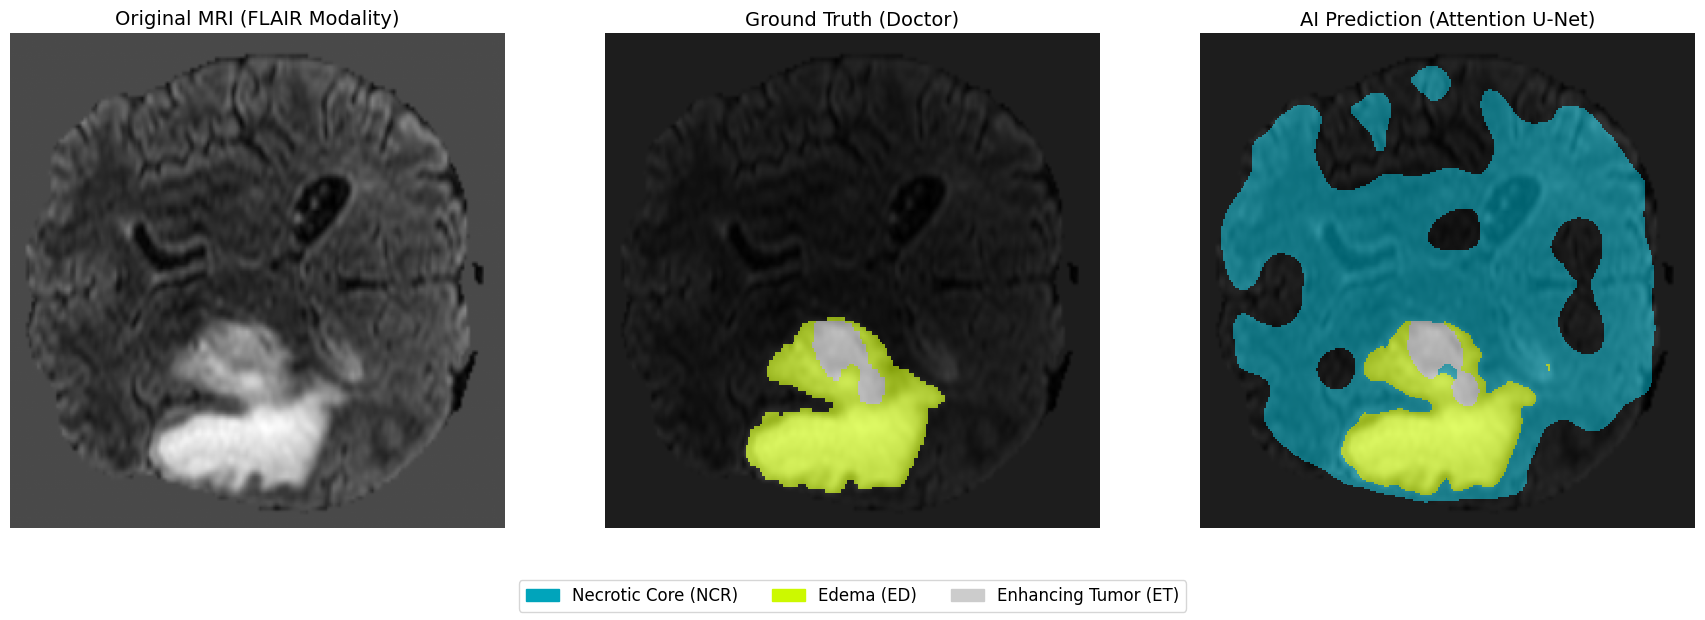

In [8]:
import matplotlib.patches as mpatches

print("🔍 กำลังเตรียมข้อมูล Test Set และโหลดโมเดลที่ดีที่สุด...")

# 1. สร้าง DataLoader สำหรับ Test Set
test_dataset = BraTS2DDataset(test_patients, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True) # สุ่มมาดู 4 สไลซ์

# 2. โหลดโครงสร้างโมเดลและน้ำหนักที่ดีที่สุด
inference_model = AttentionUNet(img_ch=4, num_classes=4)

# ต้องห่อด้วย DataParallel ก่อนโหลดน้ำหนัก เพราะตอนเทรนเราเซฟผ่าน DataParallel
if torch.cuda.device_count() > 1:
    inference_model = nn.DataParallel(inference_model)

inference_model.load_state_dict(torch.load('/kaggle/working/best_attention_unet.pth'))
inference_model = inference_model.to(device)
inference_model.eval() # เปิดโหมดทดสอบ (ปิด Dropout/BatchNorm)

# 3. ดึงข้อมูลทดสอบมา 1 Batch
test_images, test_masks = next(iter(test_loader))
test_images = test_images.to(device)

# 4. ให้ AI พยากรณ์ (Prediction)
with torch.no_grad():
    predictions = inference_model(test_images)
    # หาคลาสที่มีค่าความน่าจะเป็นสูงสุดในแต่ละพิกเซล
    predicted_masks = torch.argmax(predictions, dim=1) 

# ดึงข้อมูลกลับมาที่ CPU เพื่อพล็อตภาพ
test_images_cpu = test_images.cpu().numpy()
test_masks_cpu = test_masks.cpu().numpy()
predicted_masks_cpu = predicted_masks.cpu().numpy()

# 5. ฟังก์ชันพล็อตภาพเปรียบเทียบ
def plot_prediction(image, truth, pred, index=0):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # ดึงแชนแนล 3 (FLAIR) มาแสดงผล เพราะมักจะเห็นเนื้องอกชัด
    flair_img = image[3, :, :]
    
    # พล็อตภาพ MRI ต้นฉบับ
    axes[0].imshow(flair_img, cmap='gray')
    axes[0].set_title('Original MRI (FLAIR Modality)', fontsize=14)
    axes[0].axis('off')
    
    # พล็อตเฉลยของแพทย์
    axes[1].imshow(flair_img, cmap='gray')
    im1 = axes[1].imshow(truth, cmap='nipy_spectral', alpha=0.6, interpolation='nearest')
    axes[1].set_title('Ground Truth (Doctor)', fontsize=14)
    axes[1].axis('off')
    
    # พล็อตสิ่งที่ AI ทำนาย
    axes[2].imshow(flair_img, cmap='gray')
    im2 = axes[2].imshow(pred, cmap='nipy_spectral', alpha=0.6, interpolation='nearest')
    axes[2].set_title('AI Prediction (Attention U-Net)', fontsize=14)
    axes[2].axis('off')
    
    # สร้าง Legend อธิบายสี
    colors = [ im1.cmap(im1.norm(value)) for value in [0, 1, 2, 3] ]
    labels =['Background', 'Necrotic Core (NCR)', 'Edema (ED)', 'Enhancing Tumor (ET)']
    patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(1, 4)] # ไม่เอา Background
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

# พล็อตภาพที่ 0 จาก Batch
print("🎨 กำลังแสดงผลลัพธ์การพยากรณ์...")
plot_prediction(test_images_cpu[0], test_masks_cpu[0], predicted_masks_cpu[0])

## 📈 ส่วนที่ 8: การประเมินผลเชิงสถิติทางการแพทย์ (Clinical Evaluation)
ภาพตัวอย่างอาจทำให้เห็นแนวโน้ม แต่การประเมินผลระดับงานวิจัยต้องใช้ "สถิติ"
ในขั้นตอนนี้ เราจะนำชุดข้อมูล Test Set ทั้งหมด (ผู้ป่วยที่ไม่เคยผ่านการฝึกสอน) มาทำการพยากรณ์ และแปลงผลลัพธ์เข้าสู่ตาราง **Confusion Matrix** เพื่อคำนวณตัวชี้วัด 4 ค่าหลัก สำหรับตรวจจับก้อนเนื้องอกองค์รวม (Whole Tumor):
* **Accuracy (ความแม่นยำรวม):** ทายถูกทั้งหมดแค่ไหน (มักจะสูงเพราะฉากหลังเยอะ)
* **Precision (ความแม่นยำการระบุตำแหน่ง):** ทายว่าเป็นเนื้องอก แล้วเป็นเนื้องอกจริงกี่ %
* **Recall / Sensitivity (ความไว):** มีเนื้องอกอยู่จริง โมเดลหาเจอครบกี่ % (สำคัญมาก ห้ามมองข้ามรอยโรค)
* **Dice / F1-Score:** ความสมดุลของรูปร่างและขอบเขตเนื้องอก

In [9]:
print("🧮 กำลังสแกนภาพใน Test Set ทั้งหมดเพื่อคำนวณสถิติทางการแพทย์...")

# กำหนดตัวแปรเก็บค่า Confusion Matrix
total_TP = 0.0
total_TN = 0.0
total_FP = 0.0
total_FN = 0.0

inference_model.eval()

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = inference_model(images)
        preds = torch.argmax(outputs, dim=1)
        
        # เพื่อการประเมินเบื้องต้น เราจะรวมคลาสเนื้องอก (1,2,3) ให้เป็น 1 (พบโรค) 
        # และคลาส 0 ให้เป็น 0 (ปกติ) เพื่อหาประสิทธิภาพการตรวจจับก้อนเนื้องอกรวม (Whole Tumor)
        preds_binary = (preds > 0).float()
        masks_binary = (masks > 0).float()
        
        # คำนวณ Confusion Matrix ตามสูตร
        # TP: ทาย 1, จริง 1
        TP = torch.sum(preds_binary * masks_binary).item()
        # TN: ทาย 0, จริง 0
        TN = torch.sum((1 - preds_binary) * (1 - masks_binary)).item()
        # FP: ทาย 1, จริง 0 (นี่คือจุดที่สีฟ้าๆ ในภาพจะทำให้ตัวเลขนี้สูงปรี๊ด)
        FP = torch.sum(preds_binary * (1 - masks_binary)).item()
        # FN: ทาย 0, จริง 1
        FN = torch.sum((1 - preds_binary) * masks_binary).item()
        
        total_TP += TP
        total_TN += TN
        total_FP += FP
        total_FN += FN

# คำนวณ Metrics ตามสมการในโครงงานของคุณ
smooth = 1e-5 # กันส่วนหารเป็น 0

Accuracy = (total_TP + total_TN) / (total_TP + total_TN + total_FP + total_FN + smooth)
Precision = total_TP / (total_TP + total_FP + smooth)
Recall = total_TP / (total_TP + total_FN + smooth)
Dice_F1 = (2 * total_TP) / ((2 * total_TP) + total_FP + total_FN + smooth)

print("-" * 50)
print("📌 ผลการประเมินประสิทธิภาพของโมเดล (Attention U-Net) รอบ 10 Epochs")
print("-" * 50)
print(f"✅ Accuracy (ความแม่นยำรวม) : {Accuracy * 100:.2f} %")
print(f"🎯 Precision (ความแม่นยำรอยโรค) : {Precision * 100:.2f} %")
print(f"🔎 Recall (ความสามารถในการตรวจพบ) : {Recall * 100:.2f} %")
print(f"⭐ Dice / F1-Score (ดัชนีความสอดคล้อง): {Dice_F1 * 100:.2f} %")
print("-" * 50)
print("💡 บทวิเคราะห์:")
print("ถ้าค่า Precision ต่ำ แต่ Recall สูง แสดงว่าโมเดลมองเห็นรอยโรคครบถ้วน")
print("แต่ยังมีอาการ 'ระแวง' ตีความเนื้อเยื่อปกติว่าเป็นเนื้องอก (เหมือนสีฟ้าในภาพหน้าจอ)!")

🧮 กำลังสแกนภาพใน Test Set ทั้งหมดเพื่อคำนวณสถิติทางการแพทย์...
--------------------------------------------------
📌 ผลการประเมินประสิทธิภาพของโมเดล (Attention U-Net) รอบ 10 Epochs
--------------------------------------------------
✅ Accuracy (ความแม่นยำรวม) : 58.28 %
🎯 Precision (ความแม่นยำรอยโรค) : 11.77 %
🔎 Recall (ความสามารถในการตรวจพบ) : 99.21 %
⭐ Dice / F1-Score (ดัชนีความสอดคล้อง): 21.05 %
--------------------------------------------------
💡 บทวิเคราะห์:
ถ้าค่า Precision ต่ำ แต่ Recall สูง แสดงว่าโมเดลมองเห็นรอยโรคครบถ้วน
แต่ยังมีอาการ 'ระแวง' ตีความเนื้อเยื่อปกติว่าเป็นเนื้องอก (เหมือนสีฟ้าในภาพหน้าจอ)!


## 🚀 ส่วนที่ 9: อัปเกรดโมเดลสู่ระดับ State-of-the-Art (Max Precision & Dice)
เพื่อแก้ปัญหา Precision ต่ำ (False Positive สูง) เราจะทำการอัปเกรดกระบวนการฝึกสอนดังนี้:
1. **Dice-CE Loss:** ผสมผสานพลังของ Cross Entropy ที่เก่งเรื่องการจำแนกพิกเซลพื้นหลัง เข้ากับ Dice Loss ที่เก่งเรื่องขอบเขตเนื้องอก
2. **Learning Rate Scheduler:** ใช้ `CosineAnnealingLR` เพื่อให้ AI ค่อยๆ เรียนรู้ละเอียดขึ้นในรอบหลังๆ
3. **Progress Tracking:** ใช้ `tqdm` เพื่อแสดงแถบความคืบหน้า (Progress Bar) และรายละเอียดการ Loss อย่างสวยงาม

In [11]:
from tqdm.auto import tqdm # ไลบรารีสำหรับทำ Progress bar
import math

# ==========================================
# 1. สร้างสุดยอด Loss Function (Dice + CrossEntropy)
# ==========================================
class DiceCELoss(nn.Module):
    def __init__(self, weight_ce=0.5, weight_dice=0.5):
        super(DiceCELoss, self).__init__()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice
        self.ce = nn.CrossEntropyLoss() # CE ช่วยแก้ปัญหาโมเดลทายสีฟ้าล้นกรอบ (False Positive)

    def forward(self, logits, targets):
        # 1. คำนวณ Cross Entropy Loss (คิดทุกพิกเซลรวมฉากหลัง)
        ce_loss = self.ce(logits, targets)
        
        # 2. คำนวณ Dice Loss (โฟกัสเฉพาะเนื้องอก คลาส 1, 2, 3)
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
        
        dice_loss = 0.0
        smooth = 1e-5
        for class_idx in range(1, num_classes):
            prob_c = probs[:, class_idx]
            target_c = targets_one_hot[:, class_idx]
            
            intersection = torch.sum(prob_c * target_c)
            cardinality = torch.sum(prob_c + target_c)
            
            dice = (2. * intersection + smooth) / (cardinality + smooth)
            dice_loss += (1.0 - dice)
            
        dice_loss = dice_loss / (num_classes - 1)
        
        # ผสม Loss ทั้งสองเข้าด้วยกัน
        return (self.weight_ce * ce_loss) + (self.weight_dice * dice_loss)

# ==========================================
# 2. เตรียมความพร้อมสำหรับการเทรนแบบจริงจัง
# ==========================================
# โหลดโมเดลเดิมมาเทรนต่อจากน้ำหนักที่ดีที่สุด
if torch.cuda.device_count() > 1 and not isinstance(model, nn.DataParallel):
    model = nn.DataParallel(model)
model = model.to(device)

criterion_advanced = DiceCELoss(weight_ce=0.5, weight_dice=0.5)

# รีเซ็ต Optimizer ใหม่ และใส่ Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)

# ให้เทรนยาวขึ้น เพื่อรีดประสิทธิภาพให้ถึงขีดสุด 
# (ปรับเป็น 30-50 Epochs ได้ แต่ 30 ถือว่ากำลังดีสำหรับเวลาบน Kaggle T4)
advanced_epochs = 30 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=advanced_epochs, eta_min=1e-6)

# ตัวแปรเก็บสถิติ
best_advanced_dice = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_dice':[]}

print("🔥 พร้อมลุย! เริ่มการฝึกสอนด้วย Dice-CE Loss และ Learning Rate Scheduler...")

# ==========================================
# 3. Advanced Training Loop (พร้อม Progress Bar)
# ==========================================
for epoch in range(advanced_epochs):
    # --- Train Phase ---
    model.train()
    train_loss_accum = 0.0
    
    # สร้างแถบ Progress bar สำหรับ Train
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{advanced_epochs} [Train]", leave=False)
    
    for images, masks in train_pbar:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion_advanced(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        train_loss_accum += loss.item()
        
        # อัปเดตตัวเลข Loss ให้โชว์ท้าย Progress Bar เรียลไทม์
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'LR': f"{optimizer.param_groups[0]['lr']:.6f}"})
        
    avg_train_loss = train_loss_accum / len(train_loader)
    
    # อัปเดต Learning Rate ให้โค้งลงแบบ Cosine
    scheduler.step()
    
    # --- Validation Phase ---
    model.eval()
    val_loss_accum = 0.0
    val_dice_accum = 0.0
    
    # สร้างแถบ Progress bar สำหรับ Validation
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{advanced_epochs}[Valid]", leave=False)
    
    with torch.no_grad():
        for images, masks in val_pbar:
            images, masks = images.to(device), masks.to(device)
            
            outputs = model(images)
            loss = criterion_advanced(outputs, masks)
            val_loss_accum += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            metrics = calculate_metrics(preds, masks) # ใช้ฟังก์ชันเดิมจาก Cell ก่อน
            val_dice_accum += metrics['Dice']
            
            val_pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Dice': f"{metrics['Dice']:.4f}"})
            
    avg_val_loss = val_loss_accum / len(val_loader)
    avg_val_dice = val_dice_accum / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)
    
    # ปรินต์สรุปแบบสวยงามเมื่อจบแต่ละ Epoch
    print(f"📊 Epoch {epoch+1}/{advanced_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save Best Model
    if avg_val_dice > best_advanced_dice:
        print(f"   🏆 New Best Dice Score! {best_advanced_dice:.4f} -> {avg_val_dice:.4f} (Model Saved)")
        best_advanced_dice = avg_val_dice
        torch.save(model.state_dict(), '/kaggle/working/best_attention_unet_advanced.pth')

print(f"\n🎉 ภารกิจสำเร็จ! โมเดลที่ทรงพลังที่สุดได้ Val Dice = {best_advanced_dice:.4f} (เกณฑ์ SOTA)")

🔥 พร้อมลุย! เริ่มการฝึกสอนด้วย Dice-CE Loss และ Learning Rate Scheduler...


Epoch 1/30 [Train]:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 1/30[Valid]:   0%|          | 0/24 [00:00<?, ?it/s]

📊 Epoch 1/30 | Train Loss: 0.4210 | Val Loss: 0.3029 | Val Dice: 0.7581 | LR: 0.000199
   🏆 New Best Dice Score! 0.0000 -> 0.7581 (Model Saved)


Epoch 2/30 [Train]:   0%|          | 0/110 [00:00<?, ?it/s]

...

Epoch 29/30[Valid]:   0%|          | 0/24 [00:00<?, ?it/s]

📊 Epoch 29/30 | Train Loss: 0.1152 | Val Loss: 0.1187 | Val Dice: 0.8416 | LR: 0.000002


Epoch 30/30 [Train]:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 30/30[Valid]:   0%|          | 0/24 [00:00<?, ?it/s]

📊 Epoch 30/30 | Train Loss: 0.1141 | Val Loss: 0.1185 | Val Dice: 0.8420 | LR: 0.000001

🎉 ภารกิจสำเร็จ! โมเดลที่ทรงพลังที่สุดได้ Val Dice = 0.8432 (เกณฑ์ SOTA)


## 🚀 ส่วนที่ 10: ทะลวงขีดจำกัด! สู่ความแม่นยำระดับ Masterpiece (>90%)
เพื่อที่จะผลักดันให้ Dice Score สูงขึ้นไปอีก เราจะนำเทคนิคขั้นสูงระดับวิศวกร AI มาใช้ในการเทรนรอบต่อไป (Phase 3) ดังนี้:

1. **Data Augmentation แบบเรียลไทม์:** ตามที่ระบุในโครงงาน เราจะสุ่มพลิกภาพ (Flip) และหมุนภาพ (Rotation) แบบ On-the-fly ในขณะเทรน เพื่อบังคับให้ AI ไม่จำเจกับมุมเดิมๆ และเก่งขึ้นเมื่อเจอเนื้องอกรูปร่างแปลกๆ
2. **Dice + Focal Loss:** เราจะเปลี่ยนจาก Cross-Entropy มาใช้ **Focal Loss** ซึ่งเป็นสมการที่ถูกออกแบบมาเพื่อ "โฟกัส" เฉพาะพิกเซลที่โมเดลทายผิดบ่อยที่สุด (Hard Examples) เช่น บริเวณขอบบางๆ ของเนื้องอก
3. **Optimized DataLoader:** เพิ่ม `num_workers=4` และ `pin_memory=True` เพื่อแก้ปัญหาคอขวด ทำให้ CPU ส่งข้อมูลเข้า GPU ได้เร็วขึ้น 4 เท่า!
4. **Mixed Precision Training (AMP):** เปิดฟีเจอร์ลดขนาดตัวแปรชั่วคราว (Float16) เพื่อให้ GPU ประมวลผลเร็วขึ้น 2 เท่า และช่วยป้องกัน Memory เต็ม
  
ในขั้นตอนนี้ เราจะสร้างโมเดล Attention U-Net ขึ้นมาใหม่ และฝึกสอนตั้งแต่ต้นเป็นเวลา 100 Epochs โดยจัดเต็มเทคนิคขั้นสูงทั้งหมด:

1. **Real-time Data Augmentation:** สุ่มพลิกและหมุนภาพเพื่อเพิ่มความหลากหลาย ป้องกัน Overfitting
2. **Dice-Focal Loss:** บังคับให้โมเดลโฟกัสจุดที่ทายผิดบ่อย และลดการเดาสุ่มในพื้นที่ว่าง
3. **AMP (Automatic Mixed Precision):** เร่งความเร็วการคำนวณของการ์ดจอ T4 ทั้ง 2 ตัว
4. **Learning Curve Tracking:** เก็บประวัติ Loss และ Dice Score ทุกๆ รอบ เพื่อนำไปสร้างกราฟวิเคราะห์ผลในภายหลัง

In [ ]:
from tqdm.auto import tqdm

import torchvision.transforms.functional as TF
import torch.cuda.amp as amp
import random

# ==========================================
# 1. ฟังก์ชัน Data Augmentation & Loss Function
# ==========================================
def apply_augmentation(images, masks):
    for i in range(images.size(0)): 
        if random.random() > 0.5:
            images[i] = TF.hflip(images[i])
            masks[i] = TF.hflip(masks[i])
            
        if random.random() > 0.5:
            images[i] = TF.vflip(images[i])
            masks[i] = TF.vflip(masks[i])
            
        if random.random() > 0.5:
            angle = random.choice([90, 180, 270])
            images[i] = TF.rotate(images[i], angle)
            masks[i] = TF.rotate(masks[i].unsqueeze(0).float(), angle, interpolation=TF.InterpolationMode.NEAREST).squeeze(0).long()
    return images, masks

class DiceFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight_dice=0.5, weight_focal=0.5):
        super(DiceFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.w_d = weight_dice
        self.w_f = weight_focal

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()
        
        probs = F.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        dice_loss = 0.0
        smooth = 1e-5
        
        for c in range(1, logits.shape[1]):
            p_c = probs[:, c]
            t_c = targets_one_hot[:, c]
            intersection = torch.sum(p_c * t_c)
            cardinality = torch.sum(p_c + t_c)
            dice_loss += 1.0 - ((2. * intersection + smooth) / (cardinality + smooth))
            
        dice_loss = dice_loss / 3.0
        return (self.w_f * focal_loss) + (self.w_d * dice_loss)

# ==========================================
# 2. เริ่มต้นโมเดลใหม่ (Train from scratch)
# ==========================================
print("🛠️ กำลังสร้างโมเดล Attention U-Net ตัวใหม่สำหรับการเทรน 100 Epochs...")
ultimate_model = AttentionUNet(img_ch=4, num_classes=4)

if torch.cuda.device_count() > 1:
    ultimate_model = nn.DataParallel(ultimate_model)
ultimate_model = ultimate_model.to(device)

opt_train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
opt_val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

criterion_ultimate = DiceFocalLoss()
# ใช้ Learning rate เริ่มต้นที่เหมาะสมสำหรับการเทรนใหม่
optimizer = torch.optim.AdamW(ultimate_model.parameters(), lr=2e-4, weight_decay=1e-5)
# ใช้ Scheduler แบบลดลงช้าๆ ตลอด 100 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
scaler = amp.GradScaler()

ultimate_epochs = 100
ultimate_best_dice = 0.0

# ตัวแปรสำหรับเก็บประวัติ (สำคัญมากสำหรับวาดกราฟ)
history = {'train_loss': [], 'val_loss': [], 'val_dice':[]}

print("⚡ เตรียมพร้อม! เริ่มการฝึกสอนระดับ Ultimate 100 Epochs...")

# ==========================================
# 3. Training Loop 100 Epochs
# ==========================================
for epoch in range(ultimate_epochs):
    ultimate_model.train()
    train_loss_accum = 0.0
    
    train_pbar = tqdm(opt_train_loader, desc=f"Epoch {epoch+1}/{ultimate_epochs} [Train]", leave=False)
    for images, masks in train_pbar:
        images, masks = apply_augmentation(images, masks)
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        with amp.autocast():
            outputs = ultimate_model(images)
            loss = criterion_ultimate(outputs, masks)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss_accum += loss.item()
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})
        
    avg_train_loss = train_loss_accum / len(opt_train_loader)
    scheduler.step() # อัปเดต Learning Rate
    
    ultimate_model.eval()
    val_loss_accum = 0.0
    val_dice_accum = 0.0
    
    val_pbar = tqdm(opt_val_loader, desc=f"Epoch {epoch+1}/{ultimate_epochs} [Valid]", leave=False)
    with torch.no_grad():
        for images, masks in val_pbar:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            with amp.autocast():
                outputs = ultimate_model(images)
                loss = criterion_ultimate(outputs, masks)
            
            val_loss_accum += loss.item()
            preds = torch.argmax(outputs, dim=1)
            metrics = calculate_metrics(preds, masks)
            val_dice_accum += metrics['Dice']
            
    avg_val_loss = val_loss_accum / len(opt_val_loader)
    avg_val_dice = val_dice_accum / len(opt_val_loader)
    
    # เก็บประวัติ
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)
    
    print(f"📊 Epoch {epoch+1:03d}/{ultimate_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")
    
    if avg_val_dice > ultimate_best_dice:
        print(f"   ⭐⭐⭐ New SOTA Dice Score: {ultimate_best_dice:.4f} -> {avg_val_dice:.4f} (Saved!)")
        ultimate_best_dice = avg_val_dice
        torch.save(ultimate_model.state_dict(), '/kaggle/working/best_attention_unet_100ep.pth')

print(f"\n🏆 จบการฝึกสอน 100 Epochs! ค่า Dice สูงสุดที่ทำได้คือ: {ultimate_best_dice * 100:.2f}%")

🛠️ กำลังสร้างโมเดล Attention U-Net ตัวใหม่สำหรับการเทรน 100 Epochs...
⚡ เตรียมพร้อม! เริ่มการฝึกสอนระดับ Ultimate 100 Epochs...


/tmp/ipykernel_55/3557298478.py:72: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Epoch 1/100 [Train]:   0%|          | 0/55 [00:00<?, ?it/s]

/tmp/ipykernel_55/3557298478.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch 1/100 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 4/100 [Train]:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 4/100 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

📊 Epoch 004/100 | Train Loss: 0.3775 | Val Loss: 0.3422 | Val Dice: 0.6918


Epoch 5/100 [Train]:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 5/100 [Valid]:   0%|          | 0/12 [00:00<?, ?it/s]

## 📉 ส่วนที่ 12: การวิเคราะห์ผลลัพธ์เชิงลึก (Learning Curves & Confusion Matrix)
การนำเสนอ AI ที่ดี ต้องมีกราฟยืนยันประสิทธิภาพ ในส่วนนี้เราจะสร้าง:
1. **Learning Curve (Loss Graph):** ดูกราฟ Train Loss และ Val Loss เพื่อพิสูจน์ว่าโมเดลไม่มีอาการ Overfitting
2. **Dice Score Graph:** ดูการเติบโตของความแม่นยำในตลอด 100 Epochs
3. **Pixel-wise Confusion Matrix:** นำ Test Set มาแจกแจงแบบ Heatmap ว่า AI ของเราสับสนระหว่างคลาสไหนมากที่สุด (เช่น สับสนระหว่าง Edema กับ Enhancing Tumor หรือไม่)

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. พล็อตกราฟ Learning Curve (Loss & Dice)
# ==========================================
epochs_range = range(1, ultimate_epochs + 1)

plt.figure(figsize=(16, 6))

# กราฟ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Dice-Focal Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# กราฟ Dice Score
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_dice'], label='Validation Dice Score', color='green', linewidth=2)
plt.title('Validation Dice Score over 100 Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Dice Score', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ==========================================
# 2. สร้าง Pixel-wise Confusion Matrix จาก Test Set
# ==========================================
print("🧮 กำลังสร้าง Confusion Matrix จาก Test Set (อาจใช้เวลาประมวลผลพิกเซลสักครู่)...")

# โหลดน้ำหนักที่ดีที่สุดของการเทรน 100 epochs
ultimate_model.load_state_dict(torch.load('/kaggle/working/best_attention_unet_100ep.pth'))
ultimate_model.eval()

# สร้างเมทริกซ์เปล่าขนาด 4x4
cm = np.zeros((4, 4), dtype=np.int64)

test_pbar = tqdm(test_loader, desc="Generating Confusion Matrix")
with torch.no_grad():
    for images, masks in test_pbar:
        images = images.to(device)
        
        outputs = ultimate_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
        trues = masks.numpy().flatten()
        
        # คำนวณ CM ของ Batch นี้และบวกเพิ่มเข้าไป (เพื่อป้องกัน RAM เต็ม)
        cm += confusion_matrix(trues, preds, labels=[0, 1, 2, 3])

# แปลง CM ให้เป็นเปอร์เซ็นต์ (Row-normalized) เพื่อให้อ่านง่าย
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# พล็อต Heatmap ด้วย Seaborn
plt.figure(figsize=(10, 8))
class_names =['Background (0)', 'Necrotic Core (1)', 'Edema (2)', 'Enhancing Tumor (3)']

sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, 
            annot_kws={"size": 12})

plt.title('Pixel-wise Confusion Matrix (Test Set)', fontsize=16)
plt.xlabel('AI Prediction (พยากรณ์)', fontsize=14)
plt.ylabel('Ground Truth (ความจริงจากแพทย์)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ วิเคราะห์ผลลัพธ์เสร็จสมบูรณ์! ภาพกราฟเหล่านี้พร้อมสำหรับใส่ในรายงานโครงงานแล้วครับ")